# 04 — Multi-Platform Market Comparison

This notebook supports **Session 5 (Market Analysis + Multi-Platform Comparisons)**.

You'll:
- Load cleaned Movies + TV datasets
- Standardize fields and build a unified analysis table
- Create **pivot tables** for market comparisons
- Visualize with **stacked bar**, **grouped bar**, and **heatmap**
- Practice writing **data-backed strategic insights** (Porter / SWOT style)

> **Tip:** focus on the *question → pivot → chart → insight* loop.


## 0) Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Make plots larger and readable in class
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = Path("../data/cleaned")  # cleaned datasets produced by 01_data_cleaning.ipynb

MOVIES_PATH = DATA_DIR / "MoviesOnStreamingPlatforms_Cleaned.csv"
TV_PATH     = DATA_DIR / "TVShowsOnStreamingPlatforms_Cleaned.csv"

print('Movies file:', MOVIES_PATH)
print('TV file:    ', TV_PATH)


Movies file: /Users/joanna/Desktop/Open Avenues/Data/MoviesOnStreamingPlatforms_Cleaned.csv
TV file:     /Users/joanna/Desktop/Open Avenues/Data/TVShowsOnStreamingPlatforms_Cleaned.csv


## 1) Load Data

In [2]:
movies = pd.read_csv(MOVIES_PATH)
tv     = pd.read_csv(TV_PATH)

print("Movies shape:", movies.shape)
print("TV shape:    ", tv.shape)

display(movies.head())


Movies shape: (9515, 19)
TV shape:     (5368, 19)


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,The Irishman,2019,18+,98/100,1,0,0,0,movie,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,98.0,18.0,0,the irishman
1,2,Dangal,2016,7+,97/100,1,0,0,0,movie,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,97.0,7.0,0,dangal
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,movie,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,95.0,7.0,0,david attenborough: a life on our planet
3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,movie,"Drama, Musical, Sport","India, United States","Hindi, English",8.1,tt0169102,94.0,7.0,0,lagaan: once upon a time in india
4,5,Roma,2018,18+,94/100,1,0,0,0,movie,Drama,"Mexico, United States","Spanish, Mixtec, English, Japanese, German, Fr...",7.6,tt6155172,94.0,18.0,0,roma


## 2) Quick Data Audit (Columns + Missingness)
We want to confirm the key analysis columns exist:
- `platform` (or `Netflix`, `Hulu`, `Prime Video`, `Disney+` style indicator)
- `year` / release year
- `genre` (or a field we can map)

Because cleaned datasets can differ, we’ll **detect schema** and standardize.


In [3]:
def summarize_df(df, name):
    print(f"\n==== {name} ====")
    print("Columns:", list(df.columns))
    print("\nMissingness (top 15):")
    display(df.isna().mean().sort_values(ascending=False).head(15))
    print("\nDtypes (top 15):")
    display(df.dtypes.head(15))

summarize_df(movies, "Movies")
summarize_df(tv, "TV Shows")



==== Movies ====
Columns: ['ID', 'Title', 'Year', 'Age', 'Rotten Tomatoes', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'Type', 'Genre', 'Country', 'Language', 'IMDb', 'IMDb_ID', 'RottenTomatoes_Score', 'Age_Min', 'Type_raw', 'Title_key']

Missingness (top 15):


ID                      0.0
Genre                   0.0
Type_raw                0.0
Age_Min                 0.0
RottenTomatoes_Score    0.0
IMDb_ID                 0.0
IMDb                    0.0
Language                0.0
Country                 0.0
Type                    0.0
Title                   0.0
Disney+                 0.0
Prime Video             0.0
Hulu                    0.0
Netflix                 0.0
dtype: float64


Dtypes (top 15):


ID                   int64
Title               object
Year                 int64
Age                 object
Rotten Tomatoes     object
Netflix              int64
Hulu                 int64
Prime Video          int64
Disney+              int64
Type                object
Genre               object
Country             object
Language            object
IMDb               float64
IMDb_ID             object
dtype: object


==== TV Shows ====
Columns: ['ID', 'Title', 'Year', 'Age', 'Rotten Tomatoes', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'Type', 'Genre', 'Country', 'Language', 'IMDb', 'IMDb_ID', 'RottenTomatoes_Score', 'Age_Min', 'Type_raw', 'Title_key']

Missingness (top 15):


ID                      0.0
Genre                   0.0
Type_raw                0.0
Age_Min                 0.0
RottenTomatoes_Score    0.0
IMDb_ID                 0.0
IMDb                    0.0
Language                0.0
Country                 0.0
Type                    0.0
Title                   0.0
Disney+                 0.0
Prime Video             0.0
Hulu                    0.0
Netflix                 0.0
dtype: float64


Dtypes (top 15):


ID                  int64
Title              object
Year                int64
Age                object
Rotten Tomatoes    object
Netflix             int64
Hulu                int64
Prime Video         int64
Disney+             int64
Type               object
Genre              object
Country            object
Language           object
IMDb               object
IMDb_ID            object
dtype: object

## 3) Standardize Schema
We will build a unified table with these columns:
- `title`
- `type` (Movie / TV)
- `platform` (one row per title per platform)
- `year` (release year)
- `genre` (primary genre or a normalized genre label)

### Platform formats supported
1) A single text column like `platform`
2) Four binary columns like `Netflix`, `Hulu`, `Prime Video`, `Disney+`


In [4]:
# --- Helpers ---

PLATFORMS = [
    "Netflix", "Hulu", "Prime Video", "Disney+"
]

def melt_binary_platforms(df, platform_cols):
    # Expect platform columns are 0/1 or True/False
    tmp = df.copy()
    for c in platform_cols:
        tmp[c] = tmp[c].fillna(0)
    long = tmp.melt(
        id_vars=[c for c in tmp.columns if c not in platform_cols],
        value_vars=platform_cols,
        var_name="platform",
        value_name="on_platform"
    )
    long = long[long["on_platform"].astype(int) == 1].drop(columns=["on_platform"])
    return long

def standardize_common_fields(df):
    out = df.copy()

    # title
    if "title" not in out.columns:
        for cand in ["Title", "name", "Name"]:
            if cand in out.columns:
                out = out.rename(columns={cand: "title"})
                break

    # year
    if "year" not in out.columns:
        for cand in ["Year", "release_year", "Release Year", "released", "Release_Year"]:
            if cand in out.columns:
                out = out.rename(columns={cand: "year"})
                break

    # genre
    if "genre" not in out.columns:
        for cand in ["Genre", "genres", "listed_in", "Listed In", "category"]:
            if cand in out.columns:
                out = out.rename(columns={cand: "genre"})
                break

    # clean year
    if "year" in out.columns:
        out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")

    # clean genre: keep only the first genre if comma-separated
    if "genre" in out.columns:
        out["genre"] = out["genre"].astype(str).str.strip()
        out["genre"] = out["genre"].replace({"nan": np.nan})
        out["genre_primary"] = out["genre"].str.split(",").str[0].str.strip()
    else:
        out["genre_primary"] = np.nan

    # Rotten Tomatoes Score
    if "RottenTomatoes_Score" in out.columns:
        out["rotten_tomatoes_score"] = out["RottenTomatoes_Score"]

    return out

def standardize_to_long(df, content_type):
    df = standardize_common_fields(df)

    out = melt_binary_platforms(df, PLATFORMS)
    
    out["platform"] = out["platform"].astype(str).str.strip()

    out["type"] = content_type

    # Minimal required columns
    keep = []
    for c in ["title", "type", "platform", "year", "genre_primary", "rotten_tomatoes_score"]:
        if c in out.columns:
            keep.append(c)
    out = out[keep].copy()

    # Standardize column names
    if "genre_primary" in out.columns:
        out = out.rename(columns={"genre_primary": "genre"})
    else:
        out["genre"] = np.nan

    return out

movies_long = standardize_to_long(movies, "Movie")
tv_long     = standardize_to_long(tv, "TV Show")

df = pd.concat([movies_long, tv_long], ignore_index=True)

print("Unified df shape:", df.shape)
display(df.head())


Unified df shape: (15551, 6)


,title,type,platform,year,genre,rotten_tomatoes_score
0,The Irishman,Movie,Netflix,2019,Biography,98.0
1,Dangal,Movie,Netflix,2016,Action,97.0
2,David Attenborough: A Life on Our Planet,Movie,Netflix,2020,Documentary,95.0
3,Lagaan: Once Upon a Time in India,Movie,Netflix,2001,Drama,94.0
4,Roma,Movie,Netflix,2018,Drama,94.0


## 4) Basic Quality Checks
We’ll check for:
- Missing `platform` / `year` / `genre`
- Duplicate title-platform-type rows


In [5]:
# Missingness
display(df.isna().mean().sort_values(ascending=False))

# Duplicates (title + platform + type)
dup_mask = df.duplicated(subset=["title", "platform", "type"], keep=False)
dups = df[dup_mask].sort_values(["title", "platform", "type"])
print("Duplicate rows:", dups.shape[0])
display(dups.head(10))


title                    0.0
type                     0.0
platform                 0.0
year                     0.0
genre                    0.0
rotten_tomatoes_score    0.0
dtype: float64

Duplicate rows: 0


,title,type,platform,year,genre,rotten_tomatoes_score


## 5) Pivot Tables for Market Comparison
These pivots are the *foundation* for all charts.

### A) Total content count by platform


In [6]:
pivot_total = df.pivot_table(
    index="platform",
    values="title",
    aggfunc="count"
).rename(columns={"title": "title_count"}).sort_values("title_count", ascending=False)

display(pivot_total)


,title_count
platform,
Prime Video,5944
Netflix,5666
Hulu,2668
Disney+,1273


### B) Content count by platform and type (Movie vs TV)

In [7]:
pivot_type = df.pivot_table(
    index="platform",
    columns="type",
    values="title",
    aggfunc="count",
    fill_value=0
).sort_values(by=list(df["type"].dropna().unique()), ascending=False)

display(pivot_type)


type,Movie,TV Show
platform,,
Prime Video,4113,1831
Netflix,3695,1971
Hulu,1047,1621
Disney+,922,351


### C) Genre mix by platform (Top genres)
We’ll keep top genres to make charts readable.


In [8]:
# Determine top N genres globally
TOP_N = 10
top_genres = (df["genre"]
              .dropna()
              .value_counts()
              .head(TOP_N)
              .index.tolist())

df_topg = df[df["genre"].isin(top_genres)].copy()

pivot_genre = df_topg.pivot_table(
    index="platform",
    columns="genre",
    values="title",
    aggfunc="count",
    fill_value=0
)

display(pivot_genre)


genre,Comedy,action film,comedy drama,comedy film,documentary film,drama film,drama television series,horror film,reality television,romantic comedy
platform,,,,,,,,,,
Disney+,0,18,12,59,39,545,5,2,256,11
Hulu,4,57,66,80,101,390,87,48,978,44
Netflix,218,80,100,269,231,1515,94,50,1019,127
Prime Video,16,164,120,214,189,2089,81,139,1363,125


## 6) Charts
We will create:
- Stacked bar: **genre composition** by platform
- Grouped bar: **volume comparison** by platform and type
- Heatmap: **release year patterns** across platforms


### 6.1 Stacked Bar — Genre Composition (Top Genres)

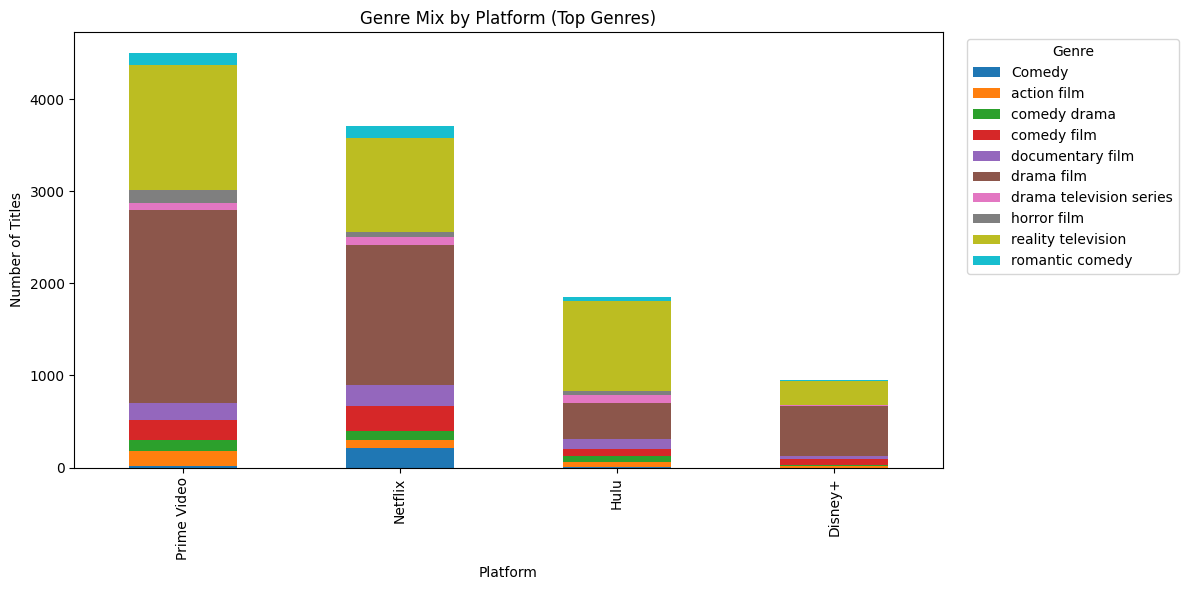

In [9]:
# Stacked bar chart from pivot table
ax = pivot_genre.loc[pivot_total.index].plot(kind="bar", stacked=True)
ax.set_title("Genre Mix by Platform (Top Genres)")
ax.set_xlabel("Platform")
ax.set_ylabel("Number of Titles")
plt.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Teaching prompt:
# - Which platform looks most diversified?
# - Which genres dominate for each platform?


### 6.2 Grouped Bar — Volume Comparison (Movies vs TV Shows)

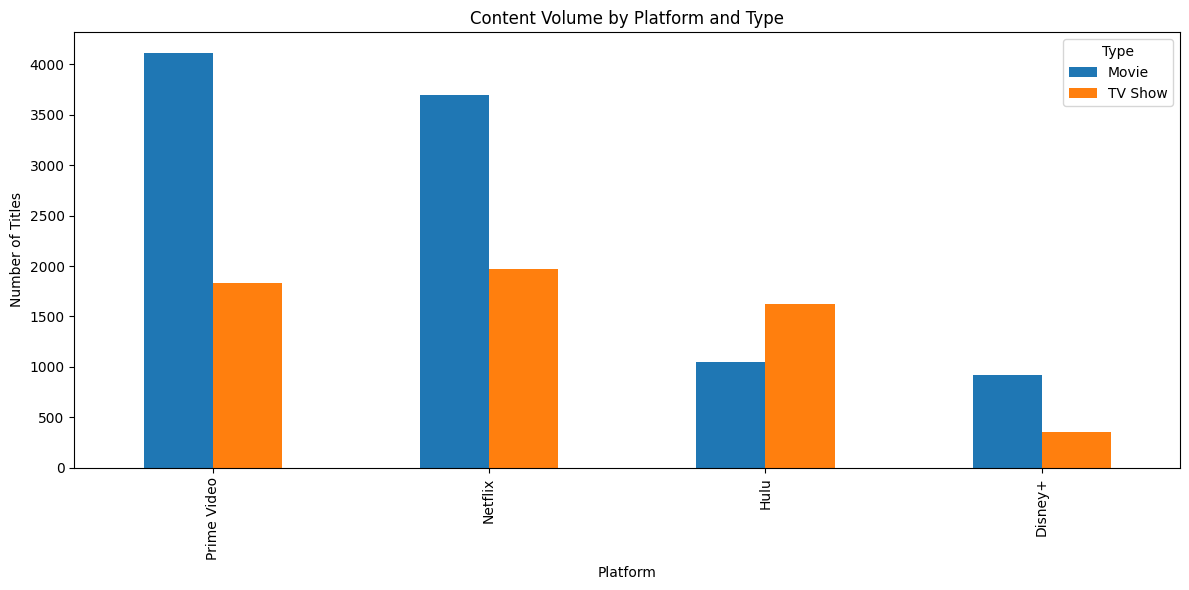

In [10]:
ax = pivot_type.loc[pivot_total.index].plot(kind="bar")
ax.set_title("Content Volume by Platform and Type")
ax.set_xlabel("Platform")
ax.set_ylabel("Number of Titles")
plt.legend(title="Type")
plt.tight_layout()
plt.show()

# Teaching prompt:
# - Which platform is strongest in movies vs TV?
# - Does a platform look 'balanced' or specialized?


### 6.3 Heatmap — Release Year Patterns by Platform
We’ll bin years into ranges to reduce noise.


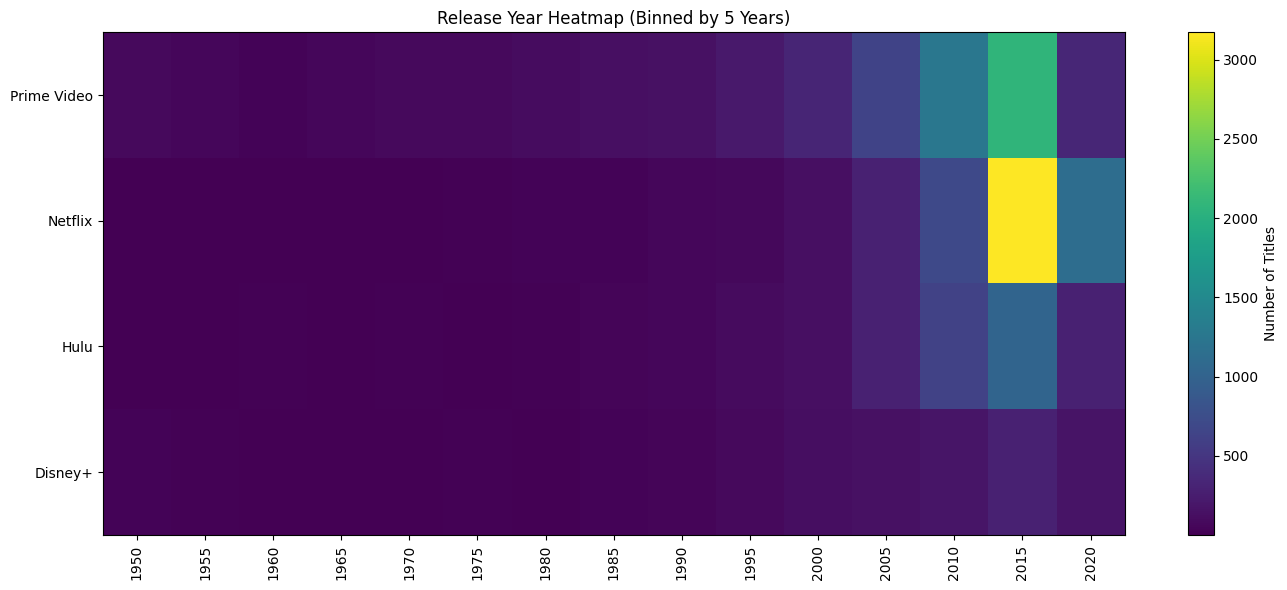

year_bin,1950,1955,1960,1965,1970,1975,1980,1985,1990,1995,2000,2005,2010,2015,2020
platform,,,,,,,,,,,,,,,
Prime Video,80,55,38,61,87,84,105,137,139,218,334,646,1255,2080,343
Netflix,2,3,6,4,9,17,34,35,57,69,132,296,697,3173,1132
Hulu,4,5,15,11,17,12,25,47,60,99,132,298,632,1018,288
Disney+,27,25,13,12,13,26,14,34,49,79,116,142,176,299,167


In [11]:
# Filter reasonable year range (optional; adjust if your data is older/newer)
df_year = df[df["year"].between(1950, 2030)].copy()

# Create year bins (e.g., 5-year buckets)
BIN_SIZE = 5
df_year["year_bin"] = (df_year["year"] // BIN_SIZE) * BIN_SIZE
df_year["year_bin"] = df_year["year_bin"].astype("Int64")

pivot_year = df_year.pivot_table(
    index="platform",
    columns="year_bin",
    values="title",
    aggfunc="count",
    fill_value=0
).loc[pivot_total.index]

# Plot heatmap using matplotlib (no seaborn)
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(pivot_year.values, aspect="auto")

ax.set_title(f"Release Year Heatmap (Binned by {BIN_SIZE} Years)")
ax.set_yticks(range(len(pivot_year.index)))
ax.set_yticklabels(pivot_year.index)

ax.set_xticks(range(len(pivot_year.columns)))
ax.set_xticklabels(pivot_year.columns, rotation=90)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of Titles")

plt.tight_layout()
plt.show()

display(pivot_year.head())


### 6.4 Box Plot — Score Distribution by Platform

/var/folders/3j/_t_cghpn36j_9y1m_x_j16rm0000gn/T/ipykernel_43166/3908649869.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=platform_order, showfliers=True)


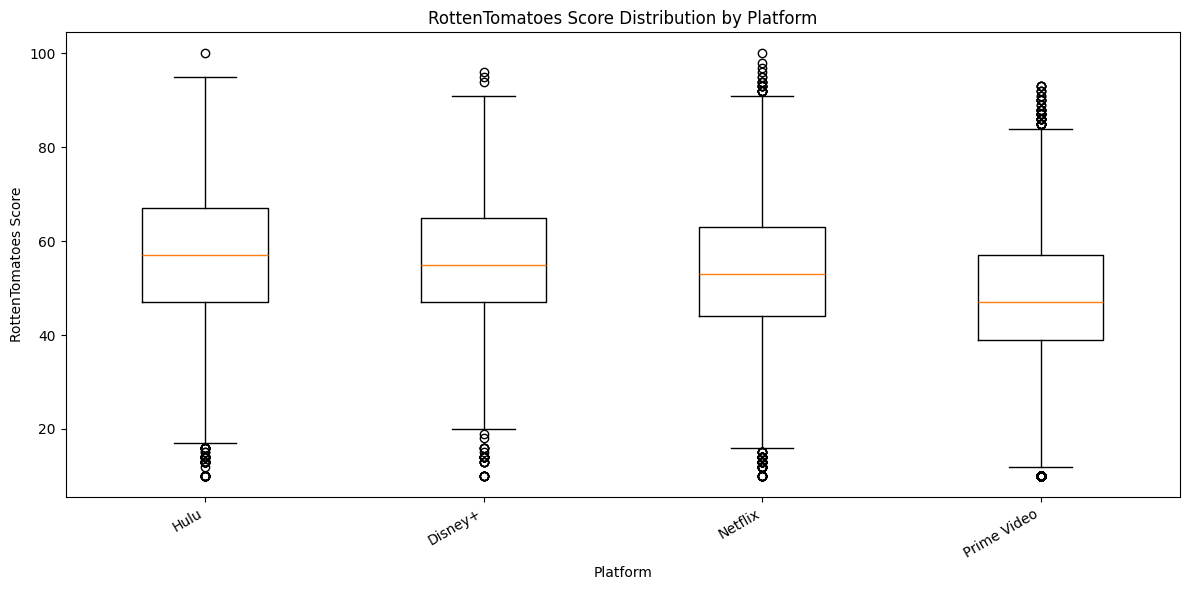

In [12]:
df_score = df.copy()
df_score["rotten_tomatoes_score"] = pd.to_numeric(df_score["rotten_tomatoes_score"], errors="coerce")

# Keep only rows with valid platform + score
df_score = df_score.dropna(subset=["platform", "rotten_tomatoes_score"])

platform_order = (
    df_score.groupby("platform")["rotten_tomatoes_score"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

data = [df_score.loc[df_score["platform"] == p, "rotten_tomatoes_score"].values for p in platform_order]

plt.figure(figsize=(12, 6))
plt.boxplot(data, labels=platform_order, showfliers=True)
plt.title("RottenTomatoes Score Distribution by Platform")
plt.xlabel("Platform")
plt.ylabel("RottenTomatoes Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 6.5 Mean score by platform and type

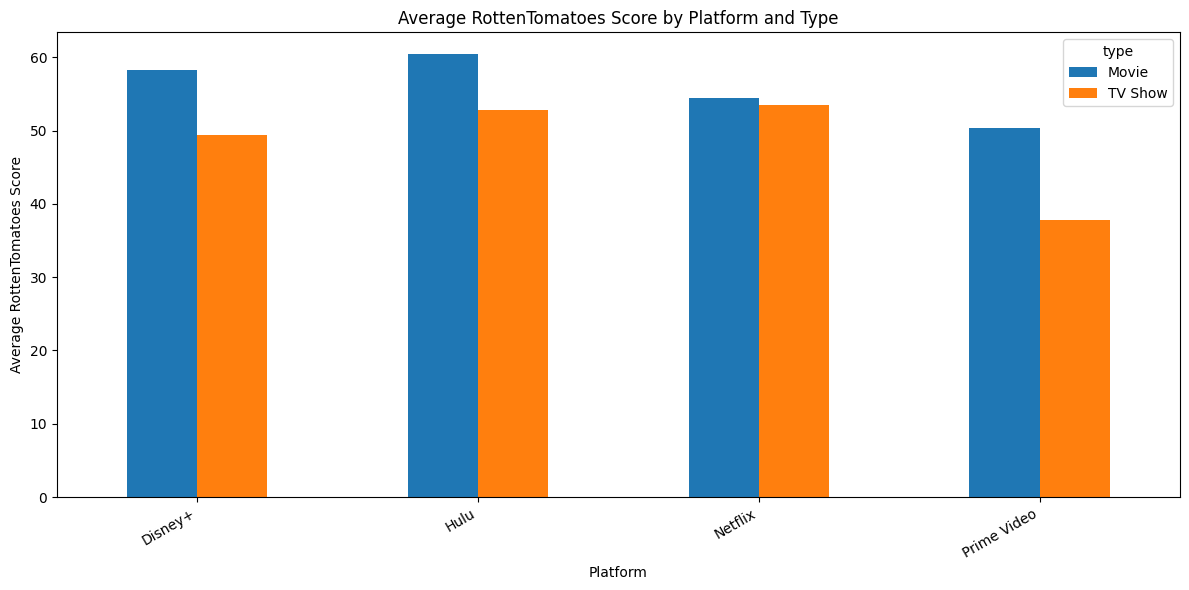

type,Movie,TV Show
platform,,
Disney+,58.312364,49.424501
Hulu,60.397326,52.837754
Netflix,54.443302,53.559107
Prime Video,50.398736,37.761333


In [13]:
summary_type = (
    df_score.groupby(["platform", "type"])["rotten_tomatoes_score"]
    .agg(["count", "mean"])
    .reset_index()
)

# Pivot for grouped bar chart
pivot_score = summary_type.pivot(index="platform", columns="type", values="mean").fillna(0)

# Order platforms by overall mean
platform_order = (
    df_score.groupby("platform")["rotten_tomatoes_score"]
    .mean()
    .sort_values(ascending=False)
    .index
)
pivot_score = pivot_score.loc[platform_order]

ax = pivot_score.plot(kind="bar")
ax.set_title("Average RottenTomatoes Score by Platform and Type")
ax.set_xlabel("Platform")
ax.set_ylabel("Average RottenTomatoes Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(pivot_score)

## 7) Interpretation: Turning Charts into Market Positioning
Use the following structure to guide discussion:

**Observation (from chart):** What do you see?

**Implication (market meaning):** Why does it matter competitively?

**Recommendation (action):** What should the platform do?

### Example sentence starters
- *"Platform X appears to differentiate via ___ because..."*
- *"Platform Y faces risk of ___ since..."*
- *"A strategic opportunity is to invest in ___ where competitors are weak..."*


In [14]:
# Quick helper to compute platform shares within top genres (optional for discussion)
genre_share = pivot_genre.div(pivot_genre.sum(axis=1), axis=0).fillna(0)
display((genre_share * 100).round(1))


genre,Comedy,action film,comedy drama,comedy film,documentary film,drama film,drama television series,horror film,reality television,romantic comedy
platform,,,,,,,,,,
Disney+,0.0,1.9,1.3,6.2,4.1,57.6,0.5,0.2,27.0,1.2
Hulu,0.2,3.1,3.6,4.3,5.4,21.0,4.7,2.6,52.7,2.4
Netflix,5.9,2.2,2.7,7.3,6.2,40.9,2.5,1.4,27.5,3.4
Prime Video,0.4,3.6,2.7,4.8,4.2,46.4,1.8,3.1,30.3,2.8
